In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

feature_data = pd.read_csv('../data/feature_house_price.csv')
model_data = feature_data.copy()
pd.set_option('display.max_columns', None)
feature_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,houseage,remoldedage,totalbathrooms,totalporchsf,totallivingarea,totaloutdoorspace,haspool,hasgarage,hasbasement,hasfireplace,hasalley
0,1,60,RL,65.0,8450,Pave,NoAlley,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NoFireplace,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NoPool,NoFence,NoMansonry,0,2,2008,WD,Normal,208500,5,5,3.5,61,2566,61,0,1,1,0,1
1,2,20,RL,80.0,9600,Pave,NoAlley,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NoMasonry,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NoPool,NoFence,NoMansonry,0,5,2007,WD,Normal,181500,31,31,2.5,0,2524,298,0,1,1,1,1
2,3,60,RL,68.0,11250,Pave,NoAlley,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NoPool,NoFence,NoMansonry,0,9,2008,WD,Normal,223500,7,6,3.5,42,2706,42,0,1,1,1,1
3,4,70,RL,60.0,9550,Pave,NoAlley,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NoMasonry,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NoPool,NoFence,NoMansonry,0,2,2006,WD,Abnorml,140000,91,36,2.0,307,2473,307,0,1,1,1,1
4,5,60,RL,84.0,14260,Pave,NoAlley,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NoPool,NoFence,NoMansonry,0,12,2008,WD,Normal,250000,8,8,3.5,84,3343,276,0,1,1,1,1


In [2]:
new_features = [
    "houseage",
    "remoldedage",
    "totalbathrooms",
    "totalporchsf",
    "totallivingarea",
    "totaloutdoorspace",
    "haspool",
    "hasgarage",
    "hasbasement",
    "hasfireplace",
    "hasalley"

]

model_data[new_features].head(10)


,houseage,remoldedage,totalbathrooms,totalporchsf,totallivingarea,totaloutdoorspace,haspool,hasgarage,hasbasement,hasfireplace,hasalley
0,5,5,3.5,61,2566,61,0,1,1,0,1
1,31,31,2.5,0,2524,298,0,1,1,1,1
2,7,6,3.5,42,2706,42,0,1,1,1,1
3,91,36,2.0,307,2473,307,0,1,1,1,1
4,8,8,3.5,84,3343,276,0,1,1,1,1
5,16,14,2.5,350,2158,70,0,1,1,0,1
6,3,2,3.0,57,3380,312,0,1,1,1,1
7,36,36,3.5,432,3197,667,0,1,1,1,1
8,77,58,2.0,205,2726,295,0,1,1,1,1
9,69,58,2.0,4,2068,4,0,1,1,1,1


In [3]:
model_data.groupby('hasalley')['SalePrice'].mean()

hasalley
1    180921.19589
Name: SalePrice, dtype: float64

In [4]:
model_data.select_dtypes(include="object").columns

C:\Users\HomePC\AppData\Local\Temp\ipykernel_8344\1924565617.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  model_data.select_dtypes(include="object").columns


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

Preparing data for modelling


In [5]:
model_data.columns = model_data.columns.str.lower()


In [6]:
model_data.select_dtypes(include=["object", "string"])

,mszoning,street,alley,lotshape,landcontour,utilities,lotconfig,landslope,neighborhood,condition1,condition2,bldgtype,housestyle,roofstyle,roofmatl,exterior1st,exterior2nd,masvnrtype,exterqual,extercond,foundation,bsmtqual,bsmtcond,bsmtexposure,bsmtfintype1,bsmtfintype2,heating,heatingqc,centralair,electrical,kitchenqual,functional,fireplacequ,garagetype,garagefinish,garagequal,garagecond,paveddrive,poolqc,fence,miscfeature,saletype,salecondition
0,RL,Pave,NoAlley,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,NoFireplace,Attchd,RFn,TA,TA,Y,NoPool,NoFence,NoMansonry,WD,Normal
1,RL,Pave,NoAlley,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,Gable,CompShg,MetalSd,MetalSd,NoMasonry,TA,TA,CBlock,Gd,TA,Gd,ALQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,NoPool,NoFence,NoMansonry,WD,Normal
2,RL,Pave,NoAlley,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Mn,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,NoPool,NoFence,NoMansonry,WD,Normal
3,RL,Pave,NoAlley,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,Gable,CompShg,Wd Sdng,Wd Shng,NoMasonry,TA,TA,BrkTil,TA,Gd,No,ALQ,Unf,GasA,Gd,Y,SBrkr,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,NoPool,NoFence,NoMansonry,WD,Abnorml
4,RL,Pave,NoAlley,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Av,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,NoPool,NoFence,NoMansonry,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Pave,NoAlley,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,NoMasonry,TA,TA,PConc,Gd,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,NoPool,NoFence,NoMansonry,WD,Normal
1456,RL,Pave,NoAlley,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,Plywood,Plywood,Stone,TA,TA,CBlock,Gd,TA,No,ALQ,Rec,GasA,TA,Y,SBrkr,TA,Min1,TA,Attchd,Unf,TA,TA,Y,NoPool,MnPrv,NoMansonry,WD,Normal
1457,RL,Pave,NoAlley,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,Gable,CompShg,CemntBd,CmentBd,NoMasonry,Ex,Gd,Stone,TA,Gd,No,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,NoPool,GdPrv,Shed,WD,Normal
1458,RL,Pave,NoAlley,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Hip,CompShg,MetalSd,MetalSd,NoMasonry,TA,TA,CBlock,TA,TA,Mn,GLQ,Rec,GasA,Gd,Y,FuseA,Gd,Typ,NoFireplace,Attchd,Unf,TA,TA,Y,NoPool,NoFence,NoMansonry,WD,Normal


In [7]:
model_data["housestyle"].value_counts(dropna=False)

housestyle
1Story    726
2Story    445
1.5Fin    154
SLvl       65
SFoyer     37
1.5Unf     14
2.5Unf     11
2.5Fin      8
Name: count, dtype: int64

In [8]:
model_data["fence"].value_counts(dropna=False)

fence
NoFence    1179
MnPrv       157
GdPrv        59
GdWo         54
MnWw         11
Name: count, dtype: int64

In [9]:
model_data.select_dtypes(include="object").nunique().sort_values()

C:\Users\HomePC\AppData\Local\Temp\ipykernel_8344\2959320114.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  model_data.select_dtypes(include="object").nunique().sort_values()


street            2
utilities         2
centralair        2
landslope         3
alley             3
paveddrive        3
masvnrtype        4
landcontour       4
exterqual         4
kitchenqual       4
garagefinish      4
lotshape          4
poolqc            4
bldgtype          5
bsmtcond          5
bsmtexposure      5
heatingqc         5
electrical        5
bsmtqual          5
miscfeature       5
fence             5
extercond         5
mszoning          5
lotconfig         5
garagequal        6
garagecond        6
fireplacequ       6
heating           6
roofstyle         6
foundation        6
salecondition     6
bsmtfintype1      7
bsmtfintype2      7
garagetype        7
functional        7
housestyle        8
roofmatl          8
condition2        8
saletype          9
condition1        9
exterior1st      15
exterior2nd      16
neighborhood     25
dtype: int64

In [10]:
model_data["kitchenqual"].value_counts()

kitchenqual
TA    735
Gd    586
Ex    100
Fa     39
Name: count, dtype: int64

In [11]:
model_data.groupby("kitchenqual")["saleprice"].mean().sort_values()

kitchenqual
Fa    105565.205128
TA    139962.511565
Gd    212116.023891
Ex    328554.670000
Name: saleprice, dtype: float64

In [12]:
model_data['garagecond'].value_counts(dropna=False)

garagecond
TA          1326
NoGarage      81
Fa            35
Gd             9
Po             7
Ex             2
Name: count, dtype: int64

In [13]:
functional_map = {
    "Sal": 0,    
    "Sev": 1,    
    "Maj2": 2,  
    "Maj1": 3,   
    "Mod": 4,    
    "Min2": 5,  
    "Min1": 6,   
    "Typ": 7     
}
fence_map = {
    "NoFence": 0,
    "MnWw": 1,
    "GdWo": 2,
    "MnPrv": 3,
    "GdPrv": 4
}

paveddrive_map = {
    "N": 1,
    "P": 2,
    "Y": 3
}

garagefinish_map = {
    "NoGarage": 0,
    "Unf": 1,
    "RFn": 2,
    "Fin": 3
}

landslope_map = {
    "Sev": 1,
    "Mod": 2,
    "Gtl": 3
}

utilities_map = {
    "AllPub" : 4,	
    "NoSewr" : 3,
    "NoSeWa" : 2,
    "ELO" : 1
}	
      
lotshape_map = {
    
       "Reg" : 4,	
       "IR1" : 3,
       "IR2" : 2,
       "IR3" : 1
}

kitchenqual_map = {
    "None": 0,
    "Fa": 1,
    "TA": 2,
    "Gd": 3,
    "Ex": 4
}

model_data["kitchenqual"] = model_data["kitchenqual"].map(kitchenqual_map)

model_data["kitchenqual"].value_counts(dropna=False)

exterqual_map = {
    "Fa":1,
    "TA":2,
    "Gd":3,
    "Ex":4
}



model_data['exterqual']=model_data['exterqual'].map(exterqual_map)
model_data["lotshape"]=model_data['lotshape'].map(lotshape_map)
model_data['utilities']=model_data['utilities'].map(utilities_map)
model_data["landslope"] = model_data["landslope"].map(landslope_map)
model_data["garagefinish"] = model_data["garagefinish"].map(garagefinish_map)
model_data["paveddrive"] = model_data["paveddrive"].map(paveddrive_map)
model_data["fence"] = model_data["fence"].map(fence_map)
model_data["functional"] = model_data["functional"].map(functional_map)
model_data['functional'].value_counts(dropna=False)

functional
7    1360
5      34
6      31
4      15
3      14
2       5
1       1
Name: count, dtype: int64

In [14]:
print(model_data["garagecond"].unique())

<StringArray>
['TA', 'Fa', 'NoGarage', 'Gd', 'Po', 'Ex']
Length: 6, dtype: str


In [15]:
quality_maps = {
    "None":0,
    "Po":1,
    "Fa":2,
    "TA":3,
    "Gd":4,
    "Ex":5
}

quality_map = {
    "NoGarage": 0,
    "NoBasement": 0,
    "NoFireplace": 0,
    "NoPool": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

model_data["garagecond"] = model_data["garagecond"].map(quality_map)
model_data['poolqc'] = model_data['poolqc'].map(quality_map)
model_data["poolqc"].value_counts(dropna=False)
model_data['fireplacequ'] = model_data['fireplacequ'].map(quality_map)
model_data["bsmtqual"] = model_data["bsmtqual"].map(quality_map)
model_data['bsmtcond'] = model_data['bsmtcond'].map(quality_map)
model_data['garagequal'] = model_data['garagequal'].map(quality_map)

model_data['bsmtcond'].value_counts(dropna=False)


bsmtcond
3    1311
4      65
2      45
0      37
1       2
Name: count, dtype: int64

In [16]:

model_data["extercond"] = model_data["extercond"].map(quality_maps)
model_data["heatingqc"] = model_data["heatingqc"].map(quality_maps)
model_data["heatingqc"].value_counts(dropna=False)
model_data["extercond"].value_counts(dropna=False)
model_data["exterqual"].unique()


array([3, 2, 4, 1])

In [17]:
bsmt_exposure_map = {
    "NoBasement": 0,
    "No": 1,
    "Mn": 2,
    "Av": 3,
    "Gd": 4
}

model_data["bsmtexposure"] = model_data["bsmtexposure"].map(bsmt_exposure_map)


model_data["bsmtqual"].value_counts(dropna=False)

bsmtqual
3    649
4    618
5    121
0     37
2     35
Name: count, dtype: int64

In [18]:
bsmt_map = {
    "NoBasement": 0,
    "Unf": 1,
    "LwQ": 2,
    "Rec": 3,
    "BLQ": 4,
    "ALQ": 5,
    "GLQ": 6
}

model_data["bsmtfintype1"] = model_data["bsmtfintype1"].map(bsmt_map)
model_data["bsmtfintype2"] = model_data["bsmtfintype2"].map(bsmt_map)

model_data["bsmtfintype1"].value_counts(dropna=False)
model_data["bsmtfintype2"].value_counts(dropna=False)

bsmtfintype2
1    1256
3      54
2      46
0      38
4      33
5      19
6      14
Name: count, dtype: int64

In [19]:
electrical_map = {
    "Mix": 1,
    "FuseP": 2,
    "FuseF": 3,
    "FuseA": 4,
    "SBrkr": 5
}

model_data["electrical"] = model_data["electrical"].map(electrical_map)

model_data["electrical"].value_counts(dropna=False)

electrical
5    1335
4      94
3      27
2       3
1       1
Name: count, dtype: int64

In [20]:
model_data.isnull().sum().sort_values(ascending=False).head(20)

id              0
mssubclass      0
mszoning        0
lotfrontage     0
lotarea         0
street          0
alley           0
lotshape        0
landcontour     0
utilities       0
lotconfig       0
landslope       0
neighborhood    0
condition1      0
condition2      0
bldgtype        0
housestyle      0
overallqual     0
overallcond     0
yearbuilt       0
dtype: int64

In [21]:
X = model_data.drop('saleprice', axis=1)
y = model_data['saleprice']

In [22]:
categorical_cols = X.select_dtypes(include="object").columns
print(categorical_cols)

Index(['mszoning', 'street', 'alley', 'landcontour', 'lotconfig',
       'neighborhood', 'condition1', 'condition2', 'bldgtype', 'housestyle',
       'roofstyle', 'roofmatl', 'exterior1st', 'exterior2nd', 'masvnrtype',
       'foundation', 'heating', 'centralair', 'garagetype', 'miscfeature',
       'saletype', 'salecondition'],
      dtype='str')


C:\Users\HomePC\AppData\Local\Temp\ipykernel_8344\3891325418.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [23]:
nominal_cols = [
    'mszoning',
    'street',
    'alley',
    'landcontour',
    'lotconfig',
    'neighborhood',
    'condition1',
    'condition2',
    'bldgtype',
    'housestyle',
    'roofstyle',
    'roofmatl',
    'exterior1st',
    'exterior2nd',
    'masvnrtype',
    'foundation',
    'heating',
    'centralair',
    'garagetype',
    'miscfeature',
    'saletype',
    'salecondition'
]

In [24]:
model_data = pd.get_dummies(
    model_data,
    columns=nominal_cols,
    drop_first=True,
    dtype=int
)

In [25]:
print(model_data.shape)

(1460, 212)


In [26]:
print(model_data.select_dtypes(include="object").columns)

Index([], dtype='str')


In [27]:
model_data.isnull().sum().sum()

np.int64(0)

In [28]:
X = model_data.drop("saleprice", axis=1)

y = model_data["saleprice"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(1168, 211)
(292, 211)


Time to train the models


In [30]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [31]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test,y_pred)

print(f"MEA : {mae:.2f}")
print(f"RMSE:{rmse:.2f}")
print(f"R2 : {r2:.4f}")

MEA : 20661.54
RMSE:31927.84
R2 : 0.8671


I have sucessfully take a raw data concerning housing price,read understand visualise and make research concerning all single colunm for the purpose of turning it into useful information that will help in predicting house price, After sucessfully cleaning the data inspecting and discovering valuaable feature data.
I am able to come up with a base model that produces a MEA of 20,661.54 A RMSE of 31927 and a R2 score of 86% 

In [32]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

I expect the Decision Tree to outperform Linear Regression because house prices depend on many complex, non-linear relationships that a tree can capture. However, if the tree grows too deep, it may overfit the training data and actually perform worse on the test set."

In [33]:
dt_mae = mean_absolute_error(y_test, dt_pred)

dt_mse = mean_squared_error(y_test, dt_pred)

dt_rmse = dt_mse ** 0.5

dt_r2 = r2_score(y_test, dt_pred)

print(f"MAE  : {dt_mae:.2f}")
print(f"RMSE : {dt_rmse:.2f}")
print(f"R²   : {dt_r2:.4f}")

MAE  : 25607.64
RMSE : 40243.44
R²   : 0.7889


In [34]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=15
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [35]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_mse = mean_squared_error(y_test, rf_pred)

rf_rmse = rf_mse ** 0.5

rf_r2 = r2_score(y_test, rf_pred)

print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

MAE  : 18015.56
RMSE : 29869.89
R²   : 0.8837


In [36]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)


In [37]:
gb_mae = mean_absolute_error(y_test, gb_pred)

gb_mse = mean_squared_error(y_test, gb_pred)

gb_rmse = gb_mse ** 0.5

gb_r2 = r2_score(y_test, gb_pred)

print(f"MAE  : {gb_mae:.2f}")
print(f"RMSE : {gb_rmse:.2f}")
print(f"R²   : {gb_r2:.4f}")

MAE  : 16085.67
RMSE : 26047.01
R²   : 0.9115


In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)
    
print(grid.best_params_)

{'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300, 'subsample': 1.0}


In [39]:
print(grid.best_score_)

0.8741210358741996


In [40]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 16643.42
RMSE : 27592.12
R²   : 0.9007


In [41]:
print(grid.best_params_)

{'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300, 'subsample': 1.0}


In [42]:
print(grid.best_score_)

0.8741210358741996


In [43]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
62,totallivingarea,0.421036
7,overallqual,0.300813
26,2ndflrsf,0.026923
60,totalbathrooms,0.024354
14,bsmtqual,0.020146
35,kitchenqual,0.018969
42,garagecars,0.018009
58,houseage,0.016076
3,lotarea,0.013830
18,bsmtfinsf1,0.013564


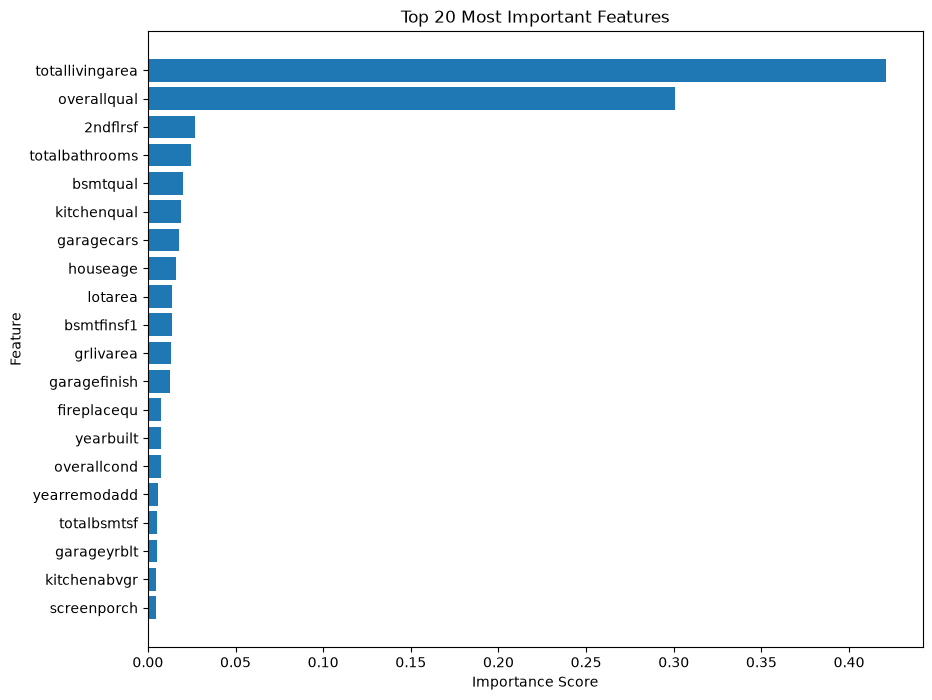

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"].head(20),
    feature_importance["Importance"].head(20)
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 20 Most Important Features")

plt.gca().invert_yaxis()

plt.show()


In [46]:
import joblib

joblib.dump(gb, "../models/house_price_model.pkl")

['../models/house_price_model.pkl']

In [47]:
joblib.dump(X_train.columns.tolist(), "../models/features.pkl")

['../models/features.pkl']